In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv('JDA.csv')

In [4]:
data

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...
1,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,Qualcomm Snapdragon 665 2 GHz Processor,4.5,"20,062 Reviews",Sunrise Design
2,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062 Reviews",Sunrise Design
3,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062 Reviews",Sunrise Design
4,4000 mAh Battery,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,MediaTek P22 Octa Core 2.0 GHz Processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot
...,...,...,...,...,...,...,...,...,...,...
979,2000 mAh Battery,5MP Rear Camera | 2MP Front Camera,12.7 cm (5 inch) FWVGA Display,1 GB RAM | 8 GB ROM | Expandable Upto 32 MB,"Micromax Bharat 4 (Black, 8 GB)",3590,12 Months Brand Warranty,3.8,105 Reviews,NaN
980,2680 mAh Li-Ion Battery,13MP Rear Camera | 5MP Front Camera,13.21 cm (5.2 inch) Full HD Display,3 GB RAM | 32 GB ROM,"Nextbit Robin (Ember, 32 GB)",19999,Qualcomm Snapdragon 808 MSM8992 Processor,4.0,516 Reviews,Brand Warranty of 1 Year
981,4550 mAh Battery,13MP + 5MP | 20MP Front Camera,15.24 cm (6 inch) Full HD Display,4 GB RAM | 64 GB ROM | Expandable Upto 256 GB,"Gionee A1 Plus (Mocha Gold, 64 GB)",10499,Helio P25 MT 6757CD Processor,4.1,710 Reviews,Brand Warranty of 1 Year Available for Mobile ...
982,2100 mAh Li-Ion Battery,8MP Rear Camera | 2MP Front Camera,12.7 cm (5 inch) HD Display,1 GB RAM | 8 GB ROM | Expandable Upto 32 GB,"XOLO Omega 5.0 (Black, 8 GB)",8990,MTK 6592M Processor,3.8,81 Reviews,1 Year Manufacturer Warranty


In [5]:
def convert_reviews_to_numeric(reviews):
    if pd.isna(reviews):
        return None
    return int(reviews.replace(' Reviews', '').replace(',', ''))


In [6]:
data['reviews'] = data['reviews'].apply(convert_reviews_to_numeric)
data['battery'] = data['battery'].str.extract('(\d+)').astype(float)
data['camera_rear'] = data['camera'].str.extract('(\d+)MP').astype(float)
data['camera_front'] = data['camera'].str.extract('\| (\d+)MP').astype(float)
data['display'] = data['display'].str.extract('(\d+\.\d+) cm').astype(float)
data['ram'] = data['memory'].str.extract('(\d+) GB RAM').astype(float)
data['rom'] = data['memory'].str.extract('(\d+) GB ROM').astype(float)
data['expandable'] = data['memory'].str.extract('Expandable Upto (\d+) GB').astype(float)

In [7]:
data_cleaned = data.drop(columns=['memory', 'camera'])

In [8]:
data_cleaned.describe(include='all')

,battery,display,name,price,processor,rating,reviews,warranty,camera_rear,camera_front,ram,rom,expandable
count,984.000000,984.000000,984,984.000000,983,971.000000,971.000000,836,984.000000,871.000000,968.000000,979.000000,692.000000
unique,NaN,NaN,878,NaN,287,NaN,NaN,92,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,"Realme C2 (Diamond Blue, 32 GB)",NaN,Qualcomm Snapdragon 730G Processor,NaN,NaN,Brand Warranty of 1 Year Available for Mobile ...,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4,NaN,21,NaN,NaN,323,NaN,NaN,NaN,NaN,NaN
mean,3821.072154,15.299522,NaN,15429.848577,NaN,4.241195,6441.051493,NaN,24.265244,14.420207,4.334711,75.378958,274.034682
std,908.890246,1.556817,NaN,12891.355967,NaN,0.300296,14962.010067,NaN,19.771064,9.176695,2.284690,66.724033,153.814815
min,1200.000000,6.100000,NaN,887.000000,NaN,2.700000,0.000000,NaN,2.000000,2.000000,1.000000,4.000000,32.000000
25%,3080.000000,14.350000,NaN,7499.000000,NaN,4.100000,107.000000,NaN,12.000000,8.000000,3.000000,32.000000,128.000000
50%,4000.000000,15.800000,NaN,11649.000000,NaN,4.300000,648.000000,NaN,13.000000,13.000000,4.000000,64.000000,256.000000
75%,4300.000000,16.360000,NaN,17999.250000,NaN,4.400000,4405.000000,NaN,48.000000,16.000000,6.000000,128.000000,400.000000


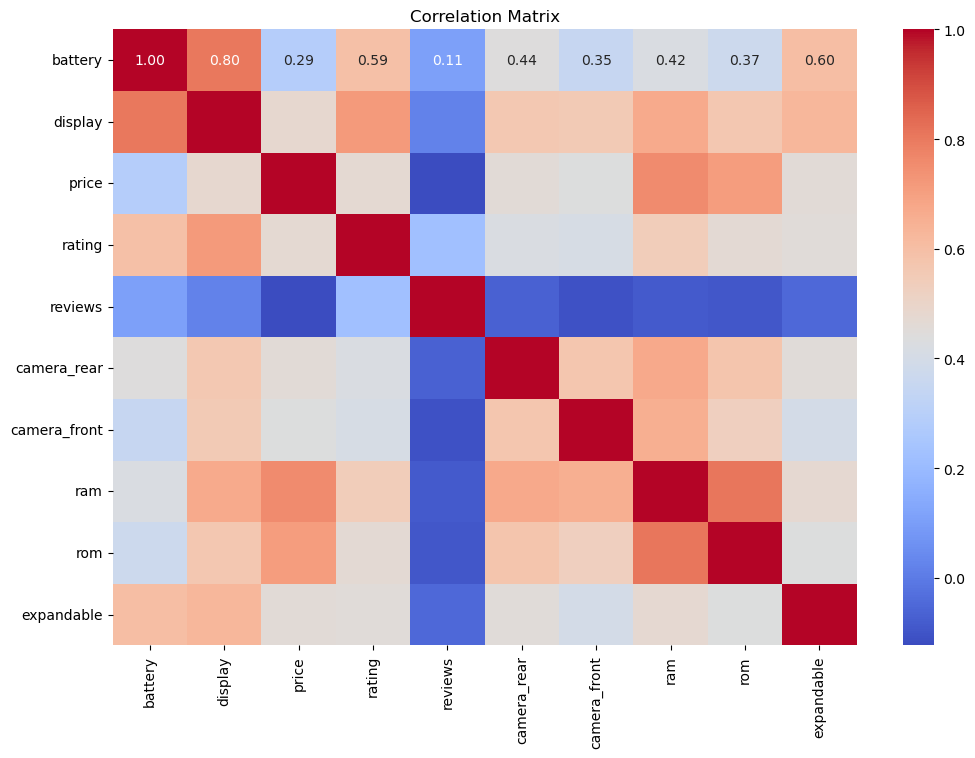

In [9]:
plt.figure(figsize=(12, 8))
corr_matrix = data_cleaned.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

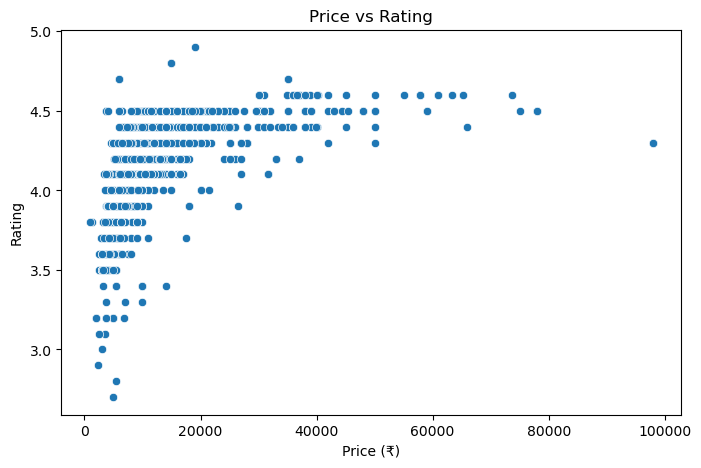

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='price', y='rating', data=data_cleaned)
plt.title("Price vs Rating")
plt.xlabel("Price (₹)")
plt.ylabel("Rating")
plt.show()

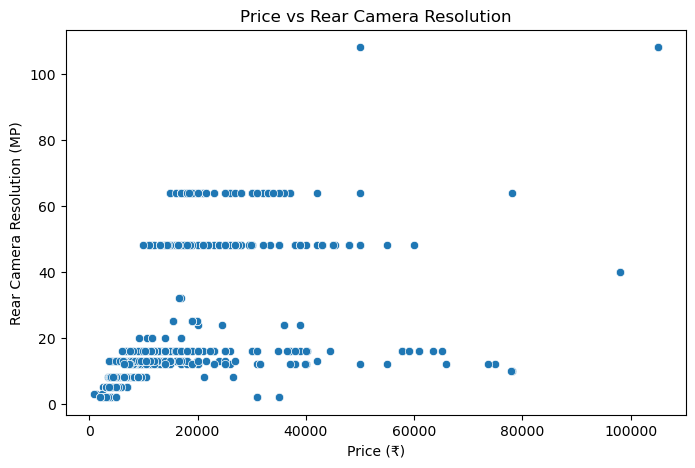

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='price', y='camera_rear', data=data_cleaned)
plt.title("Price vs Rear Camera Resolution")
plt.xlabel("Price (₹)")
plt.ylabel("Rear Camera Resolution (MP)")
plt.show()

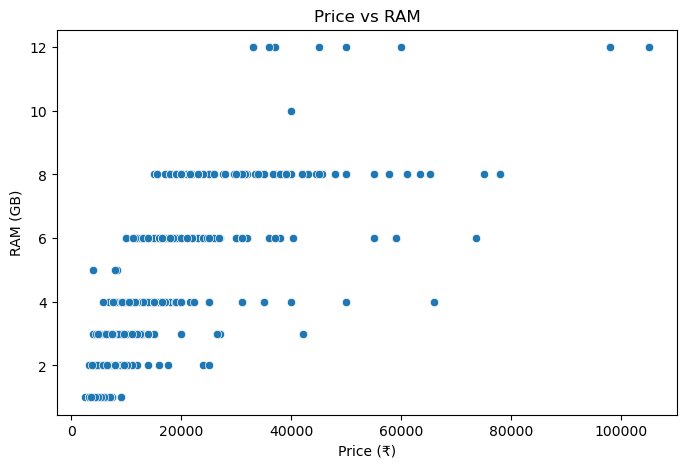

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='price', y='ram', data=data_cleaned)
plt.title("Price vs RAM")
plt.xlabel("Price (₹)")
plt.ylabel("RAM (GB)")
plt.show()

# Bonus Task A: Predict Rating based on all other existing columns

In [13]:
features = data_cleaned[['battery', 'display', 'price', 'reviews', 'camera_rear', 'camera_front', 'ram', 'rom', 'expandable']].dropna()
target = data_cleaned['rating'].dropna()

In [14]:
# Aligning target and features
common_indices = features.index.intersection(target.index)
features = features.loc[common_indices]
target = target.loc[common_indices]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [16]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(y_pred)
print(f"Mean Squared Error: {mse}")


[4.496 4.218 4.261 4.411 4.493 4.247 4.49  4.356 4.307 4.254 4.39  3.842
 3.749 4.4   4.167 4.492 4.497 4.481 4.4   4.493 4.172 4.4   4.379 4.289
 3.984 4.442 3.972 4.185 4.403 4.309 4.149 4.289 4.244 4.4   4.393 4.492
 4.496 4.287 4.357 4.264 4.4   4.115 4.295 4.404 4.129 4.4   4.21  4.388
 4.307 4.345 4.261 4.007 4.395 4.404 4.309 4.339 4.026 4.38  4.498 4.297
 4.404 4.384 4.045 4.389 4.276 4.316 4.247 4.499 4.327 4.356 4.4   4.317
 4.295 4.406 4.38  4.36  4.498 4.393 4.4   4.404 4.389 3.655 3.933 4.372
 4.492 3.977 4.293 4.026 4.419 4.009 4.468 4.498 4.303 4.041 4.306 4.372
 4.206 4.4   3.873 3.866 4.36  4.305 4.235 4.343 4.267 4.401 4.441 4.401
 4.4   3.862 4.36  4.356 4.41  4.493 4.283 4.296 4.405 3.995 4.385 4.486
 4.139 4.247 4.499 3.893 4.006 4.578 4.315 4.21  4.02 ]
Mean Squared Error: 0.01746320930232559


# Bonus Task B: Clustering of phones

In [26]:
from sklearn.cluster import AgglomerativeClustering


In [27]:
# Applying MiniBatchKMeans Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)
clusters = agg_clustering.fit_predict(clustering_features_scaled)

In [28]:
data_cleaned['cluster'] = pd.Series(clusters, index=clustering_features.index)

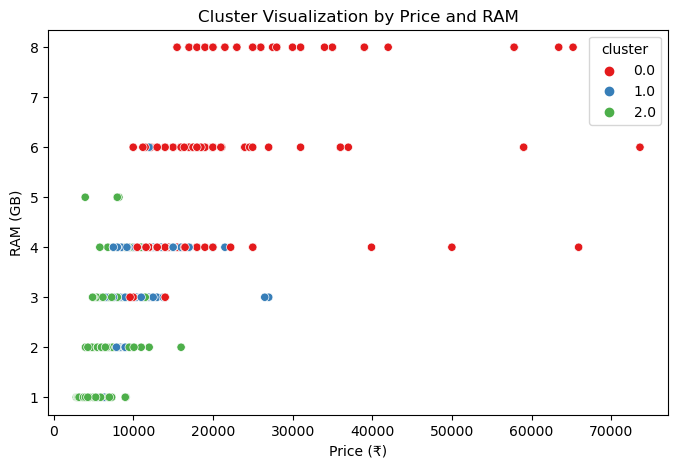

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='price', y='ram', hue='cluster', data=data_cleaned, palette='Set1')
plt.title("Cluster Visualization by Price and RAM")
plt.xlabel("Price (₹)")
plt.ylabel("RAM (GB)")
plt.show()